In [1]:
import pandas as pd
import numpy as np

In [2]:
# create an empty series 
pd.Series()

Series([], dtype: object)

In [3]:
s1 = pd.Series([1,2,3,4,5,6,7,8,9,10])
s2 = pd.Series([1,2,3,4,5,6,7,8,9,10])

In [4]:
# add 
def add_pd(s1,s2):
    return s1+s2
def sub_pd(s1,s2):
    return s1 - s2
def mul_pd(s1 , s2):
    return s1*s2
def div_pd(s1,s2):
    return s1/ s2

In [5]:
add_pd(s1,s2)
sub_pd(s1,s2)
mul_pd(s1  , s2)
div_pd(s1 , s2)

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
6    1.0
7    1.0
8    1.0
9    1.0
dtype: float64

**Q-3 Write a Pandas program to compare the elements of the two Pandas Series.**
Sample Series:
1.  [2, 4, 6, 8, 10]
2. [1, 3, 5, 7, 10]

In [6]:
s1 == s2
s1 < s2
s2 > s1

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
dtype: bool

**Q-5.Write a function to change the data type of given a column or a Series. Function takes series and data type as input, returns the converted series.**
1. series = pd.Series([1,2,'Python', 2.0, True, 100])
change to float type data
2. Note: Read about pd.to_numeric()

In [7]:
series = pd.Series([1,2,'Python', 2.0, True, 100])
def series_to_numeric(ser):
    return pd.to_numeric(ser , errors='coerce')

In [8]:
new_ser = series_to_numeric(series)
new_ser

0      1.0
1      2.0
2      NaN
3      2.0
4      1.0
5    100.0
dtype: float64

In [9]:
batsman_ser = pd.read_csv('C:/Users/Lenovo/Desktop/Python/Pandas/batsman_runs_series.csv' ,index_col='batter').squeeze()

**Q-6 Find top 10 most run getter from the batsman_series.**

In [10]:
type(batsman_ser)

pandas.Series

In [11]:
top_Ten  = batsman_ser.sort_values(ascending=False).head(10).index
top_Ten

Index(['V Kohli', 'S Dhawan', 'DA Warner', 'RG Sharma', 'SK Raina',
       'AB de Villiers', 'CH Gayle', 'MS Dhoni', 'RV Uthappa', 'KD Karthik'],
      dtype='str', name='batter')

In [12]:

for i in top_Ten:
    print(i)

V Kohli
S Dhawan
DA Warner
RG Sharma
SK Raina
AB de Villiers
CH Gayle
MS Dhoni
RV Uthappa
KD Karthik


**Q-7 No of players having runs above 3000**

In [13]:
print((batsman_ser > 3000).sum())

20


**Q-8 No of players having runs above mean value?**


In [14]:
print((batsman_ser > batsman_ser.mean()).sum())

128


**Q-9**
1. Read `items.csv` making `item_name` as index.
2. Show no of nan values
3. Item price is given in $, so convert it to rupees without currency symbol.
4. Make data type of newly made series as float.
5. Fill nan with mean of the series

In [16]:
items = pd.read_csv('C:/Users/Lenovo/Desktop/Python/Pandas/items.csv' , index_col= 'item_name').squeeze()

In [19]:
items.isna().sum()

np.int64(50)

In [24]:
items.values

<StringArray>
[ '$2.39 ',  '$3.39 ',  '$3.39 ',  '$2.39 ', '$16.98 ', '$10.98 ',       nan,
 '$11.75 ',       nan,  '$9.25 ',
 ...
  '$9.25 ',  '$2.15 ',  '$1.50 ',  '$8.75 ',  '$4.45 ', '$11.75 ', '$11.75 ',
 '$11.25 ',  '$8.75 ',  '$8.75 ']
Length: 4622, dtype: str

In [ ]:
# $ to pkr 
def to_rupee(x):
    try:
        price = x[1:]
    except Exception :
       return x
    return float(price)*275
pkr_price = items.apply(to_rupee)  

In [36]:
pkr_price

item_name
Chips and Fresh Tomato Salsa              657.25
Izze                                      932.25
Nantucket Nectar                          932.25
Chips and Tomatillo-Green Chili Salsa     657.25
Chicken Bowl                             4669.50
                                          ...   
Steak Burrito                            3231.25
Steak Burrito                            3231.25
Chicken Salad Bowl                       3093.75
Chicken Salad Bowl                       2406.25
Chicken Salad Bowl                       2406.25
Name: item_price, Length: 4622, dtype: float64

In [42]:
# 5 
pkr_price.fillna(pkr_price.mean() ,inplace=True)

item_name
Chips and Fresh Tomato Salsa              657.25
Izze                                      932.25
Nantucket Nectar                          932.25
Chips and Tomatillo-Green Chili Salsa     657.25
Chicken Bowl                             4669.50
                                          ...   
Steak Burrito                            3231.25
Steak Burrito                            3231.25
Chicken Salad Bowl                       3093.75
Chicken Salad Bowl                       2406.25
Chicken Salad Bowl                       2406.25
Name: item_price, Length: 4622, dtype: float64

**Q-10:**
1. Find mean price
2. Find 30th and 6th percentile value
3. Plot Histogram on price with bin size 50
4. No of items price lies between [1000 to 2000]

In [43]:
# 1 
pkr_price.mean()

np.float64(2052.333661417323)

In [ ]:
np.percentile(pkr_price, 30) # 30th percentile

np.float64(1223.75)

In [47]:
np.percentile(pkr_price , 6)

np.float64(343.75)

<Axes: ylabel='Frequency'>

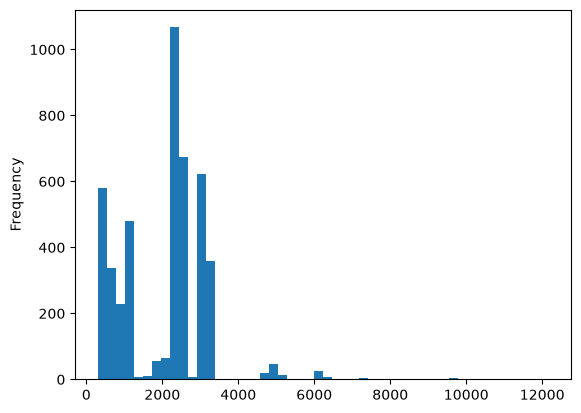

In [49]:
#  histogram with bin size 50
pkr_price.plot.hist(bins= 50)

In [55]:
# No of items price lies between [1000 to 2000]
pkr_price[pkr_price.between(1000 , 2000)]

item_name
Chips and Guacamole    1223.75
Chips and Guacamole    1223.75
Chips and Guacamole    1223.75
Chips and Guacamole    1223.75
Chips and Guacamole    1223.75
                        ...   
Chips and Guacamole    1223.75
Chips and Guacamole    1223.75
Chips and Guacamole    1223.75
Chips and Guacamole    1223.75
Chips and Guacamole    1223.75
Name: item_price, Length: 555, dtype: float64